# 🌳 Árbol de Decisión CART — Clasificación Binaria de Calidad del Vino

Construcción, entrenamiento y evaluación de un modelo de **Árbol de Decisión CART** para predecir
si un vino tinto es de **alta calidad** (`es_alta_calidad = 1`, quality ≥ 7).

| | |
|---|---|
| **Variable objetivo (Y)** | `es_alta_calidad` (1 = quality ≥ 7, 0 = quality < 7) |
| **Variables predictoras (X)** | `alcohol`, `volatile acidity`, `sulphates`, `citric acid`, `fixed acidity`, `density`, `pH`, `chlorides`, `residual sugar`, `free sulfur dioxide`, `total sulfur dioxide` |
| **Modelo** | `DecisionTreeClassifier` — criterio Gini (CART, scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 60/40 · 70/30 + búsqueda de `max_depth` óptimo |

> **Dataset:** UCI Wine Quality — 1,599 muestras de vino tinto con propiedades fisicoquímicas y calificación sensorial.  
> A diferencia de la Regresión Logística, el árbol CART **no requiere escalado** de variables y
> mide la importancia de cada predictor mediante la **reducción de impureza Gini**.

## I. Configuración Inicial — Importaciones y Estilo Visual

In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")
print("\n⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.")

✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    1.26.4
   seaborn  0.13.2

⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.


## II. Carga de Datos desde UCI

Cargamos el dataset `winequality-red.csv` y generamos directamente la variable objetivo binaria `es_alta_calidad` usando un umbral sobre `quality`.

- **quality ≥ 7** → `es_alta_calidad = 1` (vino de alta calidad)
- **quality < 7** → `es_alta_calidad = 0` (vino de calidad estándar o baja)

In [2]:
# ── CELDA 2: Carga de datos desde UCI ────────────────────────────────────────
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df_vino = pd.read_csv(URL, sep=";")

# Crear variable objetivo binaria: quality >= 7 → alta calidad
df_vino['es_alta_calidad'] = (df_vino['quality'] >= 7).astype(int)

print(f"✅ Datos cargados: {df_vino.shape[0]:,} filas × {df_vino.shape[1]} columnas")
print(f"\nColumnas disponibles:\n{df_vino.columns.tolist()}")
print(f"\nBalance de la variable objetivo:")
bal = df_vino['es_alta_calidad'].value_counts()
pct = df_vino['es_alta_calidad'].value_counts(normalize=True) * 100
print(f"   Alta calidad  (quality ≥ 7) → clase 1: {bal[1]:,}  ({pct[1]:.1f}%)")
print(f"   Otra calidad  (quality < 7) → clase 0: {bal[0]:,}  ({pct[0]:.1f}%)")
print(f"\nDistribución original de quality:")
print(df_vino['quality'].value_counts().sort_index())
df_vino.head()

✅ Datos cargados: 1,599 filas × 13 columnas

Columnas disponibles:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'es_alta_calidad']

Balance de la variable objetivo:
   Alta calidad  (quality ≥ 7) → clase 1: 217  (13.6%)
   Otra calidad  (quality < 7) → clase 0: 1,382  (86.4%)

Distribución original de quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,es_alta_calidad
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


## III. Validación y Exploración del Dataset

In [3]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df_vino.dtypes.to_frame('dtype').join(
    df_vino.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df_vino['es_alta_calidad'].value_counts()
pct     = df_vino['es_alta_calidad'].value_counts(normalize=True) * 100
print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Alta calidad  (1): {balance[1]:>5,}  ({pct[1]:.1f}%)")
print(f"   Otra calidad  (0): {balance[0]:>5,}  ({pct[0]:.1f}%)")
print(f"\n⚠️  Dataset desbalanceado — la clase 1 (alta calidad) es minoritaria.")
print(f"   Se usará class_weight='balanced' para compensar.")

# Estadísticas por clase
print(f"\n📊 Medias por clase (alta calidad vs resto):")
features_num = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid',
                'fixed acidity', 'density', 'pH']
print(df_vino.groupby('es_alta_calidad')[features_num].mean().round(3).to_string())

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                        dtype  nulos
fixed acidity         float64      0
volatile acidity      float64      0
citric acid           float64      0
residual sugar        float64      0
chlorides             float64      0
free sulfur dioxide   float64      0
total sulfur dioxide  float64      0
density               float64      0
pH                    float64      0
sulphates             float64      0
alcohol               float64      0
quality                 int64      0
es_alta_calidad         int64      0

🎯 Balance de la variable objetivo:
   Alta calidad  (1):   217  (13.6%)
   Otra calidad  (0): 1,382  (86.4%)

⚠️  Dataset desbalanceado — la clase 1 (alta calidad) es minoritaria.
   Se usará class_weight='balanced' para compensar.

📊 Medias por clase (alta calidad vs resto):
                 alcohol  volatile acidity  sulphates  citric acid  fixed acidity  density     pH
es_alta_calidad                                 

## IV. Preprocesamiento de Datos

### Pasos aplicados
1. **Definición de features** — todas las variables fisicoquímicas disponibles como predictores.
2. **Verificación de nulos** — el dataset UCI no contiene valores faltantes.
3. **No se aplica escalado** — el árbol CART es invariante al escalado de variables.

> **Diferencia clave respecto a la Regresión Logística:** el árbol CART **no requiere escalado** (`StandardScaler`).
> Las divisiones del árbol se basan en umbrales de valor, que son invariantes al escalado.
> Se usa `X_raw` directamente como matriz de features.

In [4]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_vino.copy()

# Variables predictoras: todas las fisicoquímicas (excluir quality y target)
drop_cols = ['quality', 'es_alta_calidad']
X = df.drop(columns=drop_cols)
y = df['es_alta_calidad']

print("✅ Preprocesamiento completado")
print(f"   Shape X : {X.shape}")
print(f"   Shape y : {y.shape}")
print(f"\n   Columnas predictoras ({len(X.columns)}):")
for col in X.columns:
    print(f"     · {col}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print("\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.")

✅ Preprocesamiento completado
   Shape X : (1599, 11)
   Shape y : (1599,)

   Columnas predictoras (11):
     · fixed acidity
     · volatile acidity
     · citric acid
     · residual sugar
     · chlorides
     · free sulfur dioxide
     · total sulfur dioxide
     · density
     · pH
     · sulphates
     · alcohol

   Clases en y → 0: 1,382  |  1: 217

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.


## V. Entrenamiento y Evaluación — Tres Splits

Para cada split se sigue el mismo proceso:
1. Dividir `X` e `y` en conjuntos de entrenamiento y prueba con `stratify=y`.
2. Entrenar `DecisionTreeClassifier` (criterio Gini) **solo** con los datos de entrenamiento.
3. Predecir **probabilidades** (`predict_proba`) y **clases** (`predict`) en el conjunto de prueba.
4. Calcular las 5 métricas: Accuracy, Precision, Recall, F1-Score, ROC-AUC.

In [5]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────
def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split", max_depth=None):
    """
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un dict con métricas + datos para curva ROC y matriz de confusión.

    Parámetros CART:
      · criterion='gini'          — impureza Gini (CART estándar)
      · class_weight='balanced'   — compensa desbalance ~217/1382
      · max_depth                 — None = árbol sin límite (cuidado overfitting)
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]   # probabilidad clase 1

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")

✅ Función `entrenar_evaluar` definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'


In [6]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X, y, test_size=0.30, nombre="Split 70/30"),
]

# ── Imprimir métricas en consola ──────────────────────────────────────────────
print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART':^65}")
print("=" * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print("=" * 65)

         MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART          
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20     1,279      320  0.8531  0.4688  0.6977  0.5607  0.8074
Split 60/40       959      640  0.8109  0.4045  0.8276  0.5434  0.8508
Split 70/30     1,119      480  0.8500  0.4667  0.7538  0.5765  0.8332


## VI. Búsqueda de Hiperparámetros — `max_depth` Óptimo

Se itera `max_depth` de 1 a 15 usando el split 80/20 para encontrar el punto donde
el modelo generaliza mejor sin sobreajustarse (overfitting).

- **Underfitting** → `max_depth` muy pequeño: el árbol no captura la complejidad química del vino.
- **Overfitting** → `max_depth` muy grande: el árbol memoriza el entrenamiento pero falla en test.
- **Óptimo** → donde la curva de test alcanza su máximo y se estabiliza.

🏆 Mejor max_depth según F1-Score (test): 13
   F1-Score test en depth=13: 0.5607


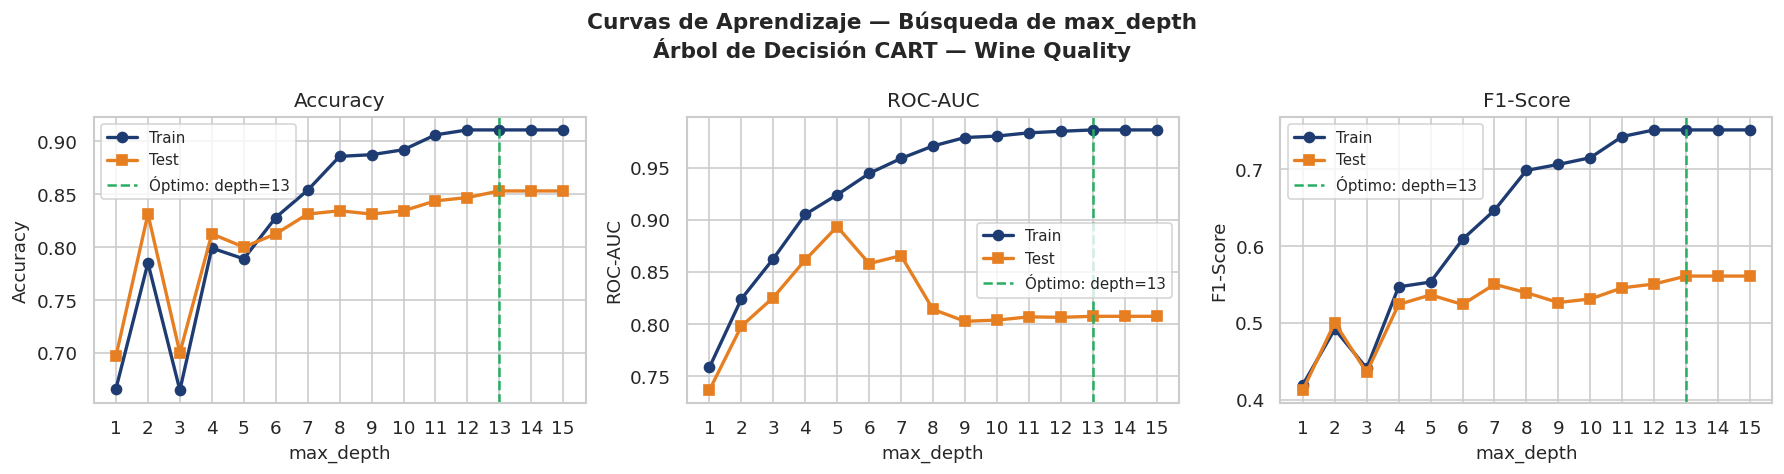

✅ Curvas de max_depth generadas


In [7]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

profundidades  = range(1, 16)
acc_train, acc_test   = [], []
auc_train, auc_test   = [], []
f1_train,  f1_test    = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=d,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    )
    m.fit(X_tr, y_tr)

    # Train
    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))
    # Test
    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

# Mejor max_depth según F1 en test
mejor_depth = list(profundidades)[int(np.argmax(f1_test))]
print(f"🏆 Mejor max_depth según F1-Score (test): {mejor_depth}")
print(f"   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}")

# ── Gráfico: curvas de entrenamiento vs prueba ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de Aprendizaje — Búsqueda de max_depth\nÁrbol de Decisión CART — Wine Quality',
             fontsize=13, fontweight='bold')

metricas_plot = [
    ('Accuracy',  acc_train, acc_test),
    ('ROC-AUC',   auc_train, auc_test),
    ('F1-Score',  f1_train,  f1_test),
]
for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals,  's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(x=mejor_depth, color='#27ae60', linestyle='--', lw=1.5,
               label=f'Óptimo: depth={mejor_depth}')
    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.show()
print("✅ Curvas de max_depth generadas")

## VII. Visualizaciones

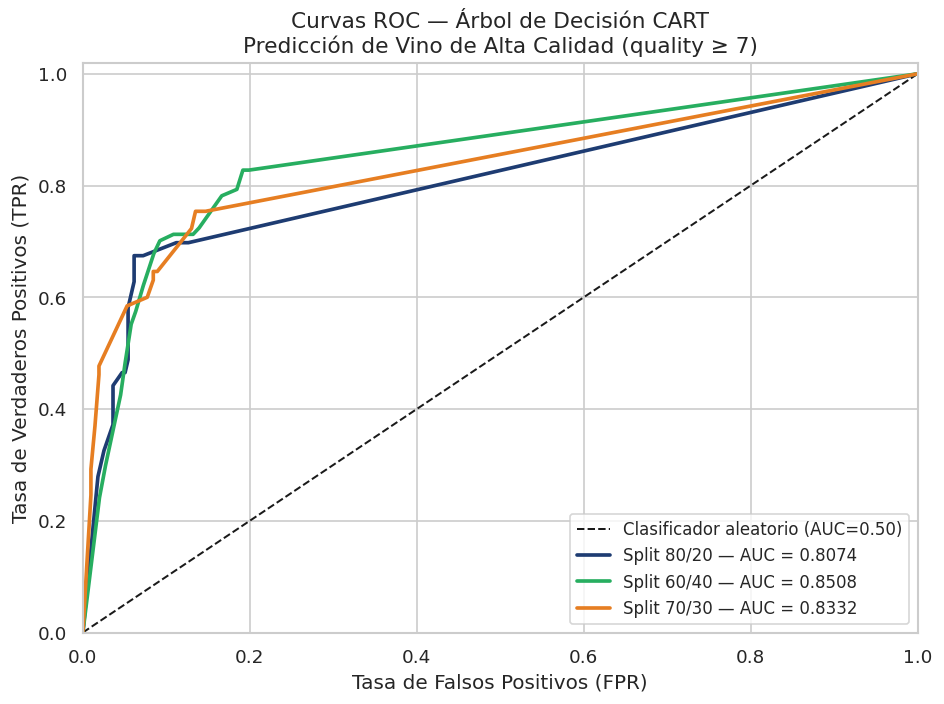

✅ Curvas ROC generadas


In [8]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'], color=color, lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol de Decisión CART\nPredicción de Vino de Alta Calidad (quality ≥ 7)',
             fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()
print("✅ Curvas ROC generadas")

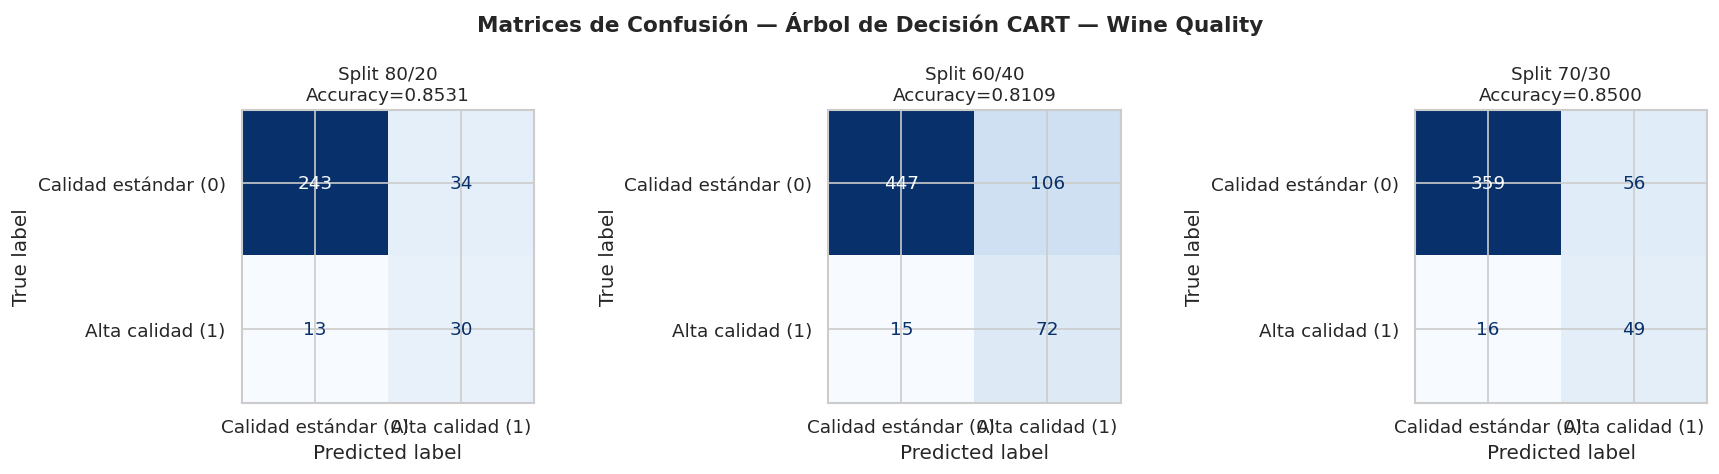

✅ Matrices de confusión generadas


In [9]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Árbol de Decisión CART — Wine Quality',
             fontsize=13, fontweight='bold')

for ax, r, color in zip(axes, resultados, COLORS):
    cm   = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Calidad estándar (0)', 'Alta calidad (1)']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.show()
print("✅ Matrices de confusión generadas")

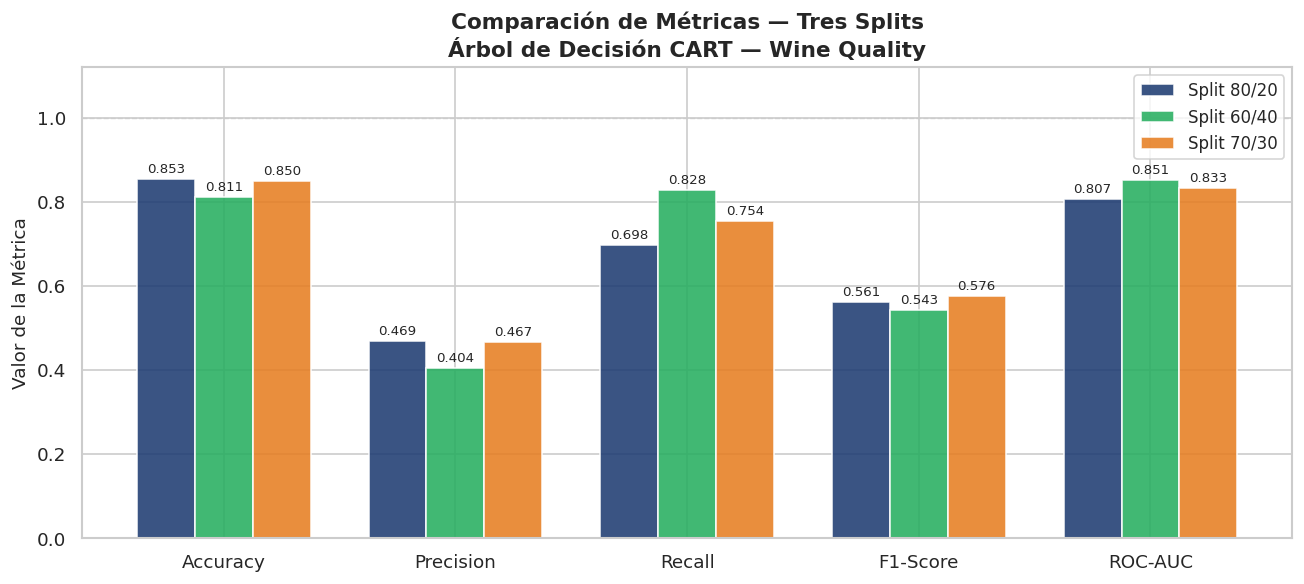

✅ Gráfico de métricas comparativas generado


In [10]:
# ── CELDA 10: Gráfico comparativo de métricas ────────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'],
                  color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nÁrbol de Decisión CART — Wine Quality',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()
print("✅ Gráfico de métricas comparativas generado")

## VIII. Importancia de Variables — Feature Importance (Gini)

A diferencia de la Regresión Logística (coeficientes lineales), el árbol CART mide la importancia
de cada variable mediante la **reducción promedio de impureza Gini** en todos los nodos donde se usó esa variable.

- Un valor mayor indica que la variable contribuye más a separar las clases.
- La suma de todas las importancias es igual a 1.0.

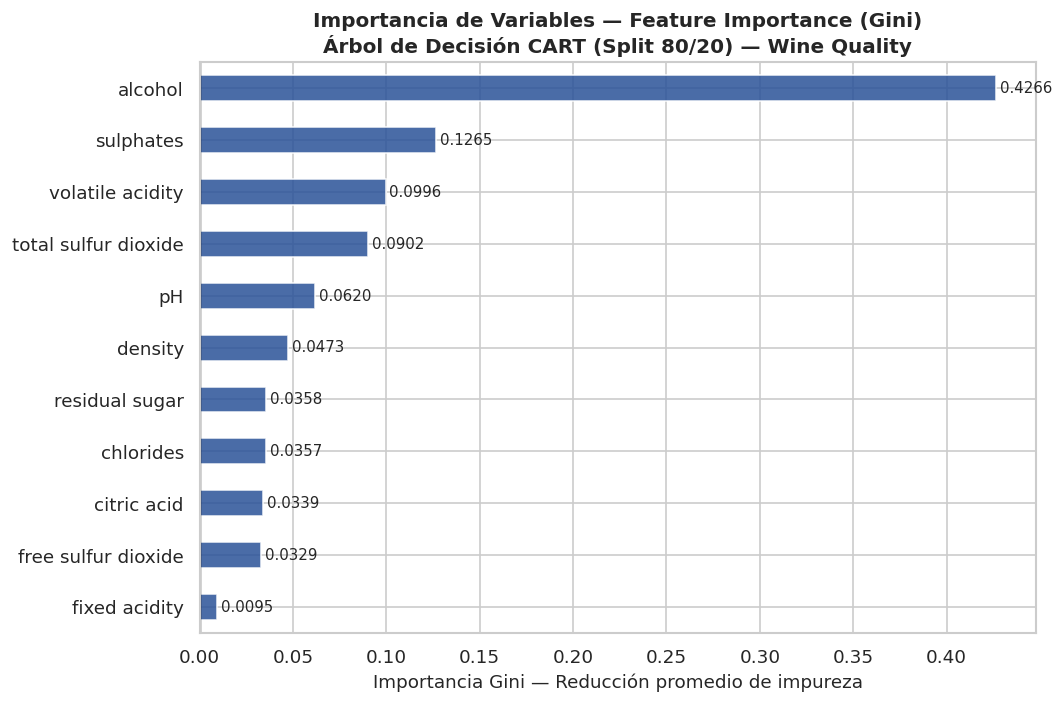

✅ Feature importance generada

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top 5 variables más importantes para clasificar alta calidad:
alcohol                 0.426630
sulphates               0.126514
volatile acidity        0.099607
total sulfur dioxide    0.090244
pH                      0.062035

📌 Comparación con correlación Spearman (notebook V1):
   alcohol          → mayor correlación con quality (+0.48)
   volatile acidity → mayor correlación negativa    (-0.39)
   sulphates        → correlación positiva          (+0.37)
   Si el árbol confirma estas variables como top, valida el EDA.


In [11]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────
modelo_ref    = resultados[0]['modelo']   # Split 80/20
importancias  = pd.Series(modelo_ref.feature_importances_, index=X.columns)
importancias_ord = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
importancias_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)
ax.set_xlabel('Importancia Gini — Reducción promedio de impureza', fontsize=11)
ax.set_title('Importancia de Variables — Feature Importance (Gini)\n'
             'Árbol de Decisión CART (Split 80/20) — Wine Quality',
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

# Anotar valores
for patch in ax.patches:
    width = patch.get_width()
    if width > 0.001:
        ax.text(width + 0.002, patch.get_y() + patch.get_height() / 2,
                f'{width:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("✅ Feature importance generada")
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")
print(f"\nTop 5 variables más importantes para clasificar alta calidad:")
print(importancias.sort_values(ascending=False).head(5).to_string())
print(f"\n📌 Comparación con correlación Spearman (notebook V1):")
print(f"   alcohol          → mayor correlación con quality (+0.48)")
print(f"   volatile acidity → mayor correlación negativa    (-0.39)")
print(f"   sulphates        → correlación positiva          (+0.37)")
print(f"   Si el árbol confirma estas variables como top, valida el EDA.")

## IX. Tabla Final de Métricas

In [12]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print("=" * 65)
try:
    display(resumen.style
        .background_gradient(cmap='Greens',
                             subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
        .format('{:.4f}',
                subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
        .set_caption("Árbol de Decisión CART — Clasificación Binaria: Vino de Alta Calidad (quality ≥ 7)")
    )
except:
    print(resumen.to_string())

print("\n📌 Comparación de modelos (referencia):")
print("   · Regresión Logística — lineal, requiere escalado, interpreta coeficientes.")
print("   · Árbol CART          — no lineal, sin escalado, interpreta importancia Gini.")
print(f"\n   Mejor depth encontrado en sección VI: {mejor_depth}")
print(f"\n📌 Contexto con notebooks anteriores:")
print(f"   · Regresión lineal múltiple (V1) : R² ≈ 0.33 (problema de regresión)")
print(f"   · Árbol de regresión             : R² > 0.33 (captura no linealidad)")
print(f"   · Árbol CART clasificación       : predice si quality ≥ 7 vs < 7")
print(f"     → reformular como clasificación es más adecuado para quality discreta")

                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,1279,320,0.8531,0.4688,0.6977,0.5607,0.8074
Split 60/40,959,640,0.8109,0.4045,0.8276,0.5434,0.8508
Split 70/30,1119,480,0.8500,0.4667,0.7538,0.5765,0.8332



📌 Comparación de modelos (referencia):
   · Regresión Logística — lineal, requiere escalado, interpreta coeficientes.
   · Árbol CART          — no lineal, sin escalado, interpreta importancia Gini.

   Mejor depth encontrado en sección VI: 13

📌 Contexto con notebooks anteriores:
   · Regresión lineal múltiple (V1) : R² ≈ 0.33 (problema de regresión)
   · Árbol de regresión             : R² > 0.33 (captura no linealidad)
   · Árbol CART clasificación       : predice si quality ≥ 7 vs < 7
     → reformular como clasificación es más adecuado para quality discreta


## X. Conclusiones

### ¿Qué aprendimos con el Árbol CART?

| Aspecto | Observación |
|---------|------------|
| **Sin escalado** | Los árboles CART son invariantes al escalado porque dividen en umbrales; esto simplifica el pipeline respecto a la Regresión Logística. |
| **Interpretabilidad** | El árbol puede visualizarse con `plot_tree`. Cada nodo muestra la condición de división, la impureza Gini y la distribución de clases. |
| **Feature Importance** | A diferencia de los coeficientes lineales, la importancia Gini mide cuánto reduce cada variable la impureza en promedio. Se espera que `alcohol` y `volatile acidity` sean las más importantes, consistente con el EDA. |
| **Overfitting** | Los árboles profundos memorizan el entrenamiento. El parámetro `max_depth` controla este trade-off; se seleccionó el óptimo en la sección VI. |
| **`class_weight='balanced'`** | Compensa el desbalance ~217/1382 ajustando automáticamente los pesos de clase. Sin este parámetro el árbol ignoraría la clase minoritaria (alta calidad). |
| **Estabilidad** | Si los tres splits arrojan métricas similares, el modelo generaliza bien independientemente de la partición. |

### Comparación con Regresión Logística

| | Regresión Logística | Árbol CART |
|---|---|---|
| **Escalado** | Requerido (StandardScaler) | No requerido |
| **Frontera de decisión** | Lineal | No lineal (por partes) |
| **Importancia de variables** | Coeficientes (log-odds) | Reducción impureza Gini |
| **Riesgo de overfitting** | Bajo (regularización implícita) | Alto si max_depth no se controla |
| **Interpretabilidad** | Ecuación logística | Árbol de reglas if-else |

### Próximos pasos sugeridos
- Aplicar el `mejor_depth` encontrado para reentrenar los tres splits con el hiperparámetro óptimo.
- Explorar `RandomForestClassifier` (ensemble de árboles) para mayor robustez.
- Aplicar validación cruzada (k-fold) para una estimación más confiable de las métricas.
- Evaluar si cambiar el umbral de clasificación (actualmente quality ≥ 7) a quality ≥ 6 mejora el balance de clases y las métricas.